In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())


(5000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           5000 non-null   int64  
 1   visit_date           5000 non-null   object 
 2   age_group            5000 non-null   object 
 3   gender               5000 non-null   object 
 4   region               5000 non-null   object 
 5   department           5000 non-null   object 
 6   treatment_type       5000 non-null   object 
 7   visit_type           5000 non-null   object 
 8   length_of_stay_days  5000 non-null   float64
 9   treatment_cost       5000 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 390.8+ KB
None
        patient_id  length_of_stay_days  treatment_cost
count  5000.000000          5000.000000     5000.000000
mean   2500.500000             4.059660    54915.471800
std    1443.520003             1.928847    19

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(df.isnull().sum())
print(df.duplicated().sum())


patient_id             0
visit_date             0
age_group              0
gender                 0
region                 0
department             0
treatment_type         0
visit_type             0
length_of_stay_days    0
treatment_cost         0
dtype: int64
0


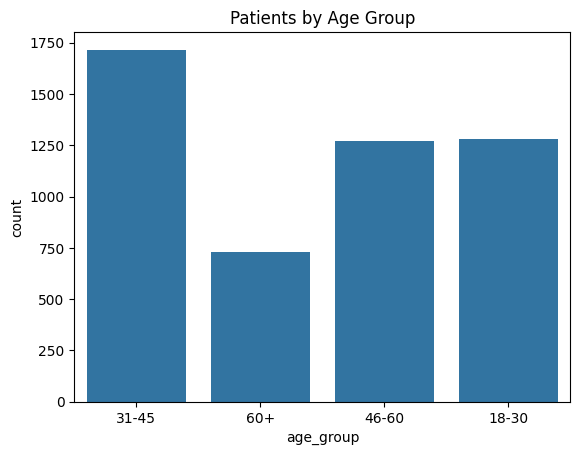

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="age_group")
plt.title("Patients by Age Group")
plt.show()


In [ ]:
print(df["gender"].value_counts())


gender
Male      2508
Female    2492
Name: count, dtype: int64


In [ ]:
print(df["department"].value_counts())


department
Orthopedics         1058
Cardiology           995
General Medicine     991
Pediatrics           989
Neurology            967
Name: count, dtype: int64


In [ ]:
print(df["treatment_type"].value_counts())


treatment_type
Observation    1270
Surgery        1262
Medication     1236
Therapy        1232
Name: count, dtype: int64


In [ ]:
print(df["visit_type"].value_counts())


visit_type
Routine      3432
Emergency    1568
Name: count, dtype: int64


In [ ]:
print(df["treatment_cost"].mean())
print(df["treatment_cost"].median())
print(df["treatment_cost"].max())
print(df["treatment_cost"].min())


54915.4718
55123.5
119307.0
746.0


In [ ]:
import numpy as np

cost = df["treatment_cost"]

print("Average Cost:", np.mean(cost))
print("Minimum Cost:", np.min(cost))
print("Maximum Cost:", np.max(cost))


Average Cost: 54915.4718
Minimum Cost: 746
Maximum Cost: 119307


In [ ]:
print(df["length_of_stay_days"].mean())
print(df["length_of_stay_days"].median())


4.05966
4.0


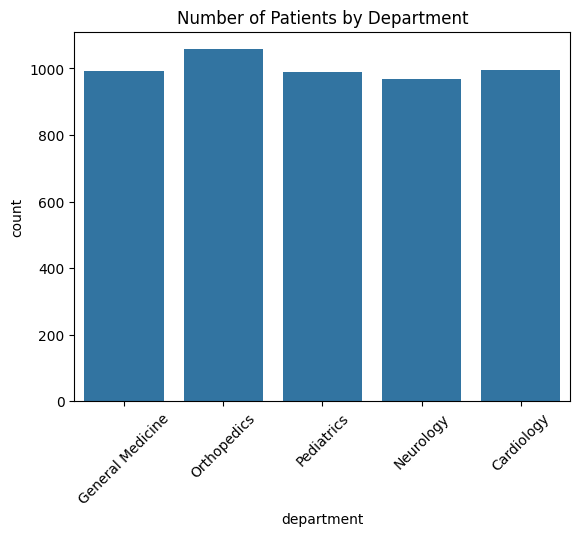

In [ ]:
sns.countplot(data=df, x="department")
plt.title("Number of Patients by Department")
plt.xticks(rotation=45)
plt.show()


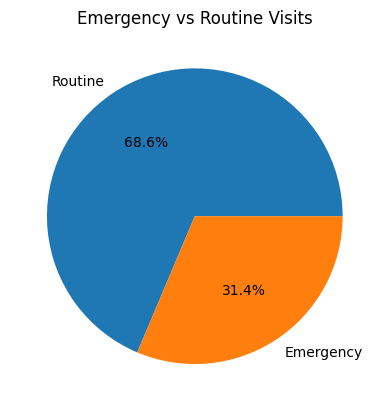

In [ ]:
df["visit_type"].value_counts().plot(
   kind="pie",
   autopct="%1.1f%%"
)
plt.title("Emergency vs Routine Visits")
plt.ylabel("")
plt.show()


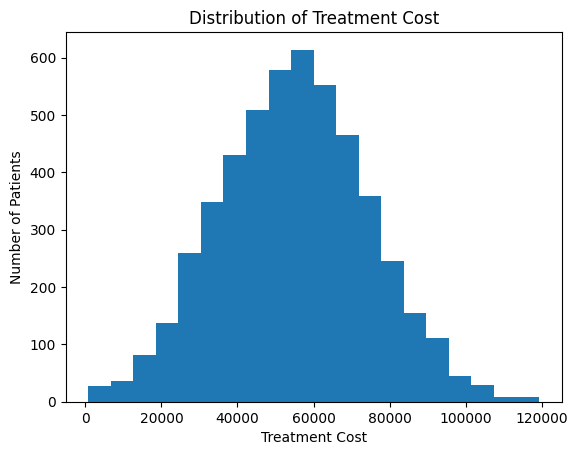

In [ ]:
plt.hist(df["treatment_cost"], bins=20)
plt.title("Distribution of Treatment Cost")
plt.xlabel("Treatment Cost")
plt.ylabel("Number of Patients")
plt.show()


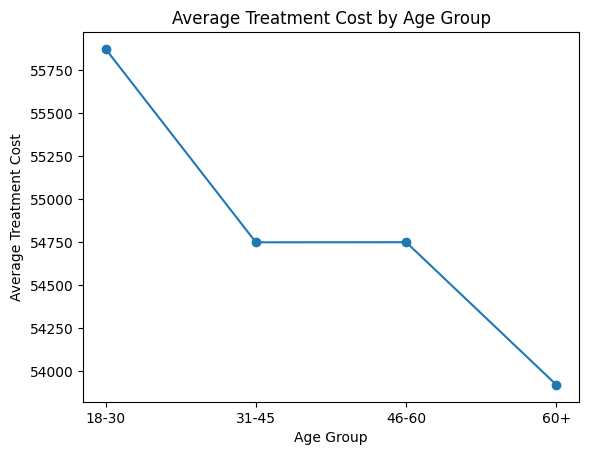

In [ ]:
avg_cost = df.groupby("age_group")["treatment_cost"].mean()
plt.plot(avg_cost.index, avg_cost.values, marker="o")
plt.title("Average Treatment Cost by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Treatment Cost")
plt.show()


In [ ]:
print(df["treatment_cost"].mean())
print(df["treatment_cost"].median())
print(df["treatment_cost"].std())


54915.4718
55123.5
19481.160486870056


In [ ]:
print(
   df[["length_of_stay_days", "treatment_cost"]].corr()
)


                     length_of_stay_days  treatment_cost
length_of_stay_days             1.000000       -0.022281
treatment_cost                 -0.022281        1.000000


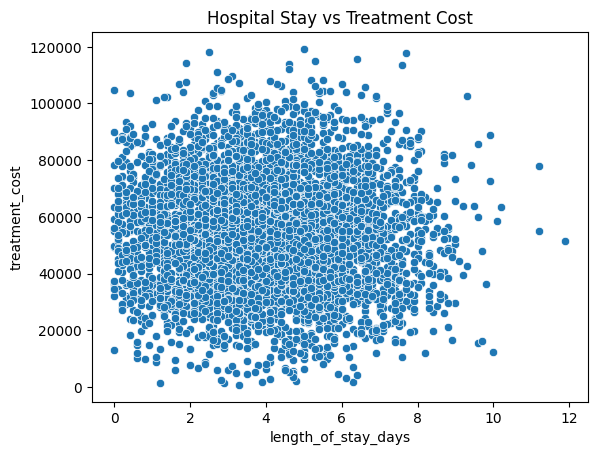

In [ ]:
sns.scatterplot(
   data=df,
   x="length_of_stay_days",
   y="treatment_cost"
)
plt.title("Hospital Stay vs Treatment Cost")
plt.show()


In [11]:
import plotly.express as px

fig = px.scatter(
    df,
    x="length_of_stay_days",
    y="treatment_cost",
    color="visit_type",
    title="Hospital Stay vs Treatment Cost",
    labels={
        "length_of_stay_days": "Length of Stay (Days)",
        "treatment_cost": "Treatment Cost (₹)",
        "visit_type": "Visit Type"
    }
)

fig.update_layout(
    width=900,
    height=600
)

fig.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor


df = pd.read_csv("healthcare_patient_analytics.csv")

encoders = {}

columns = [
    "age_group",
    "gender",
    "department",
    "treatment_type",
    "visit_type"
]

for col in columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])


X_stay = df[
    [
        "age_group",
        "gender",
        "department",
        "treatment_type",
        "visit_type"
    ]
]

y_stay = df["length_of_stay_days"]

stay_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

stay_model.fit(X_stay, y_stay)


X_cost = df[
    [
        "age_group",
        "gender",
        "department",
        "treatment_type",
        "visit_type",
        "length_of_stay_days"
    ]
]

y_cost = df["treatment_cost"]

cost_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

cost_model.fit(X_cost, y_cost)



print("\n=== PATIENT DETAILS ===\n")

age = input(
    "Enter Age Group (18-30, 31-45, 46-60, 60+): "
)

gender = input(
    "Enter Gender (Male/Female): "
)

treatment = input(
    "Enter Treatment Type: "
)

department = input(
    "Enter Department: "
)

visit = input(
    "Enter Visit Type (Emergency/Routine): "
)


patient = pd.DataFrame({
    "age_group": [
        encoders["age_group"].transform([age])[0]
    ],

    "gender": [
        encoders["gender"].transform([gender])[0]
    ],

    "department": [
        encoders["department"].transform([department])[0]
    ],

    "treatment_type": [
        encoders["treatment_type"].transform([treatment])[0]
    ],

    "visit_type": [
        encoders["visit_type"].transform([visit])[0]
    ]
})


predicted_stay = stay_model.predict(patient)[0]

# Create minimum and maximum stay
min_stay = max(1, round(predicted_stay - 2))
max_stay = max(min_stay, round(predicted_stay + 2))



# Predict cost using predicted average stay
patient_base = patient.copy()

patient_base["length_of_stay_days"] = round(predicted_stay)

base_cost = cost_model.predict(patient_base)[0]



# Calculate average cost per hospital day
cost_per_day = df["treatment_cost"].sum() / df["length_of_stay_days"].sum()

# ==========================================
# 10. CALCULATE MINIMUM AND MAXIMUM COST
# ==========================================

# Keep base cost related to patient condition
# and adjust it according to stay duration.

min_cost = base_cost - (
    (predicted_stay - min_stay) * cost_per_day
)

max_cost = base_cost + (
    (max_stay - predicted_stay) * cost_per_day
)

# Make sure maximum cost is always >= minimum cost
if max_cost < min_cost:
    max_cost = min_cost



print("-- HEALTHCARE PREDICTION --")

print("\nPatient Details")
print("-------------------")

print("Age Group       :", age)
print("Gender          :", gender)
print("Treatment       :", treatment)
print("Department      :", department)
print("Visit Type      :", visit)

print("\n-- PREDICTION --")

print("\nMinimum Prediction")
print("Length of Stay  :", min_stay, "days")
print("Treatment Cost  : ₹", round(min_cost, 2))

print("\nMaximum Prediction")
print("Length of Stay  :", max_stay, "days")
print("Treatment Cost  : ₹", round(max_cost, 2))




=== PATIENT DETAILS ===

Enter Age Group (18-30, 31-45, 46-60, 60+): 46-60
Enter Gender (Male/Female): Male
Enter Treatment Type: Surgery
Enter Department: Cardiology
Enter Visit Type (Emergency/Routine): Emergency
-- HEALTHCARE PREDICTION --

Patient Details
-------------------
Age Group       : 46-60
Gender          : Male
Treatment       : Surgery
Department      : Cardiology
Visit Type      : Emergency

-- PREDICTION --

Minimum Prediction
Length of Stay  : 2 days
Treatment Cost  : ₹ 14263.62

Maximum Prediction
Length of Stay  : 6 days
Treatment Cost  : ₹ 68372.06
